<a href="https://colab.research.google.com/github/sanchezmicaela/Aprendizaje_Automatico/blob/main/2_Wine_aa_micaela_sanchez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score

In [ ]:
wine = load_wine()

X = wine.data
y = wine.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Tamaño de entrenamiento:", X_train.shape)
print("Tamaño de prueba:", X_test.shape)

Tamaño de entrenamiento: (142, 13)
Tamaño de prueba: (36, 13)


In [ ]:
knn_original = KNeighborsClassifier()

knn_original.fit(X_train, y_train)

pred_original = knn_original.predict(X_test)

accuracy_original = accuracy_score(
    y_test,
    pred_original
)

print("Accuracy con datos originales:", accuracy_original)

Accuracy con datos originales: 0.8055555555555556


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
knn_scaled = KNeighborsClassifier()

knn_scaled.fit(X_train_scaled, y_train)

pred_scaled = knn_scaled.predict(X_test_scaled)

accuracy_scaled = accuracy_score(
    y_test,
    pred_scaled
)

print("Accuracy con StandardScaler:", accuracy_scaled)

Accuracy con StandardScaler: 0.9722222222222222


In [ ]:
selector = SelectKBest(
    score_func=f_classif,
    k=5
)

X_train_selected = selector.fit_transform(
    X_train_scaled,
    y_train
)

X_test_selected = selector.transform(
    X_test_scaled
)

print("Cantidad de atributos originales:", X_train_scaled.shape[1])
print("Cantidad de atributos seleccionados:", X_train_selected.shape[1])

Cantidad de atributos originales: 13
Cantidad de atributos seleccionados: 5


In [ ]:
knn_selected = KNeighborsClassifier()

knn_selected.fit(
    X_train_selected,
    y_train
)

pred_selected = knn_selected.predict(
    X_test_selected
)

accuracy_selected = accuracy_score(
    y_test,
    pred_selected
)

print(
    "Accuracy con StandardScaler + SelectKBest:",
    accuracy_selected
)

Accuracy con StandardScaler + SelectKBest: 0.9722222222222222


In [ ]:
print(
    "Accuracy con datos originales:",
    round(accuracy_original, 4)
)

print(
    "Accuracy con StandardScaler:",
    round(accuracy_scaled, 4)
)

print(
    "Accuracy con StandardScaler + SelectKBest:",
    round(accuracy_selected, 4)
)

Accuracy con datos originales: 0.8056
Accuracy con StandardScaler: 0.9722
Accuracy con StandardScaler + SelectKBest: 0.9722


In [ ]:
selected_features = np.array(wine.feature_names)[
    selector.get_support()
]

print("Atributos seleccionados:")

for feature in selected_features:
    print("-", feature)

Atributos seleccionados:
- alcohol
- flavanoids
- color_intensity
- od280/od315_of_diluted_wines
- proline


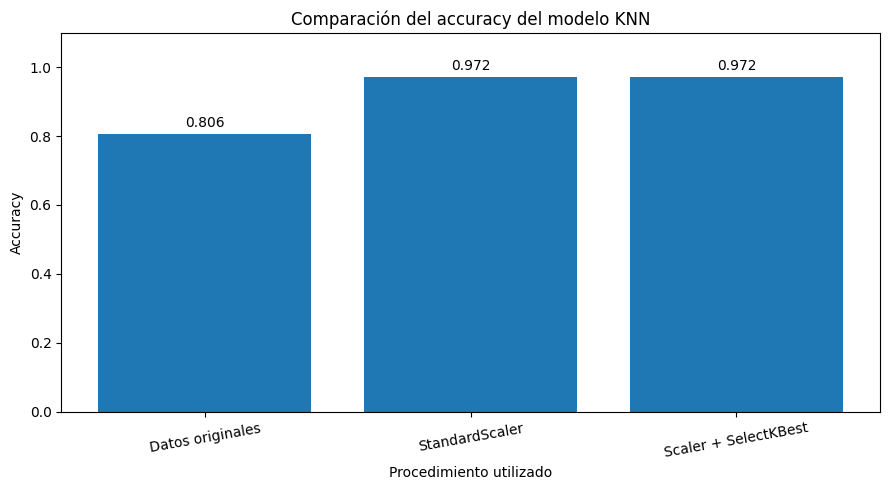

In [ ]:
metodos = [
    "Datos originales",
    "StandardScaler",
    "Scaler + SelectKBest"
]

resultados = [
    accuracy_original,
    accuracy_scaled,
    accuracy_selected
]

plt.figure(figsize=(9, 5))

bars = plt.bar(
    metodos,
    resultados
)

plt.ylim(0, 1.10)
plt.ylabel("Accuracy")
plt.xlabel("Procedimiento utilizado")
plt.title("Comparación del accuracy del modelo KNN")

for barra, valor in zip(bars, resultados):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        valor + 0.02,
        f"{valor:.3f}",
        ha="center"
    )

plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

## Interpretación de resultados

*El modelo KNN entrenado con los datos originales obtuvo un accuracy de 0.8056. Esto indica que aproximadamente el 80.56% de las muestras del conjunto de prueba fueron clasificadas correctamente.*

*Al aplicar StandardScaler, el accuracy aumentó a 0.9722. Esta mejora se debe a que KNN utiliza distancias para realizar las clasificaciones, por lo que las diferencias de escala entre las variables pueden afectar negativamente el rendimiento. La estandarización permite que todas las características tengan una influencia comparable en el cálculo de distancias.*

*Posteriormente se aplicó SelectKBest para seleccionar los cinco atributos más relevantes. El accuracy obtenido fue nuevamente de 0.9722. Esto demuestra que es posible reducir la cantidad de variables sin perder capacidad predictiva, ya que los atributos seleccionados contienen gran parte de la información necesaria para distinguir las clases del dataset Wine.*

*El preprocesamiento mediante StandardScaler produjo una mejora importante en el rendimiento del modelo, mientras que la selección de características permitió simplificar el conjunto de datos manteniendo el mismo nivel de precisión.*